<a href="https://colab.research.google.com/github/ShajeeaMinnath/Digit-Recognition-ML/blob/feature%2Fmodeling/Model_Training_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# --- STEP 1: LOAD THE DATASET (Member B needs this too!) ---
print("Loading MNIST dataset...")
X_raw, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X_raw = X_raw.astype('float32')
y = y.astype('int')

Loading MNIST dataset...


In [3]:
# --- STEP 2: APPLY MEMBER A'S FEATURE EXTRACTION ---
# Note: Member B uses Member A's logic here to get the HOG features
def extract_features(image):
    img_2d = image.reshape((28, 28))
    raw_pixels = image / 255.0  # Normalize

    # HOG Features
    hog_feats = hog(img_2d, orientations=9, pixels_per_cell=(7, 7),
                    cells_per_block=(2, 2), visualize=False)

    # We'll use the raw + HOG combination for the model
    return np.hstack([raw_pixels, hog_feats])

print("Extracting features... (this might take 1-2 minutes)")
X_features = np.array([extract_features(img) for img in X_raw])

Extracting features... (this might take 1-2 minutes)


In [4]:
# --- STEP 3: SPLIT THE DATA ---
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, random_state=42)

In [5]:
# --- STEP 4: SCALING & PCA (Stage 5 & 6) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dimensionality Reduction to 100 components
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Variance explained by 100 components: {np.sum(pca.explained_variance_ratio_):.2%}")

Variance explained by 100 components: 66.79%


In [6]:
# --- STEP 5: TRAIN SVM WITH RBF KERNEL (Stage 6) ---
print("Training SVM... this may take a moment.")
svm_model = SVC(kernel='rbf', C=10, gamma='scale')
svm_model.fit(X_train_pca, y_train)

Training SVM... this may take a moment.


SVC(C=10)

In [7]:
# --- STEP 6: EVALUATION (Stage 7) ---
y_pred = svm_model.predict(X_test_pca)
print("\n--- SVM CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))


--- SVM CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      1.00      0.99      1600
           2       0.98      0.99      0.98      1380
           3       0.99      0.98      0.98      1433
           4       0.98      0.99      0.98      1295
           5       0.99      0.99      0.99      1273
           6       0.99      0.99      0.99      1396
           7       0.97      0.98      0.98      1503
           8       0.98      0.97      0.98      1357
           9       0.98      0.97      0.98      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



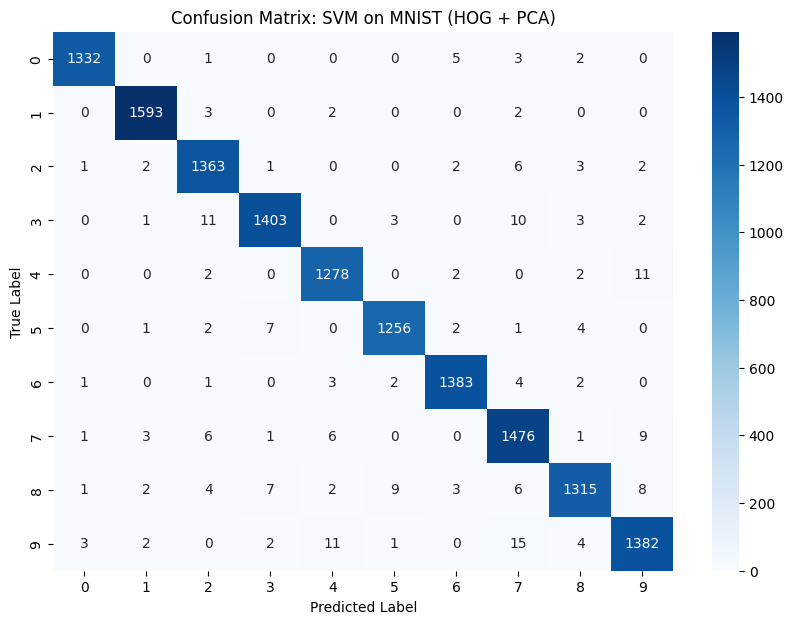

In [8]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: SVM on MNIST (HOG + PCA)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()